# Exercise 2 — Feature importance

**PCS956 • Module C • Week 1**

## Research question

**When a decision tree says a feature is important, what exactly does that mean?**

This notebook focuses on one Week 1 concept: impurity-based feature importance for decision trees.

We will:

- train a decision tree on the same Titanic data;
- compute impurity-based feature importance;
- connect the ranking back to the tree structure;
- test how the ranking changes with tree depth;
- examine stability under resampling;
- discuss limitations without introducing permutation importance or the model-specific/model-agnostic taxonomy.


## Dataset: Titanic

We use the same Titanic passenger dataset throughout all four Week 1 practical notebooks so that the **data remain fixed while the explanation question changes**.

Each row represents one passenger. The target is:

- `survived = 1` — the passenger was recorded as surviving;
- `survived = 0` — the passenger was recorded as not surviving.

We use these predictors:

| Feature | Meaning |
|---|---|
| `pclass` | Passenger class: 1st, 2nd, or 3rd |
| `sex` | Recorded sex |
| `age` | Age in years |
| `sibsp` | Number of siblings/spouses aboard |
| `parch` | Number of parents/children aboard |
| `fare` | Passenger fare |
| `embarked` | Port of embarkation |

The seaborn version of the dataset contains missing values, including missing `age` and `embarked` values. Preprocessing is therefore fitted **only on the training data** and then applied to the test data.

### Scientific caution

This is historical observational data. These notebooks investigate **model behaviour**. Feature importance, decision rules, and SHAP attributions should not be interpreted as causal effects on survival.


## 1. Setup and preprocessing


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

RANDOM_STATE = 42

titanic = sns.load_dataset("titanic")

FEATURES = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]
TARGET = "survived"

X = titanic[FEATURES].copy()
y = titanic[TARGET].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                drop="if_binary"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(
    X_train,
    columns=feature_names,
    index=X_train_raw.index
)

X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names,
    index=X_test_raw.index
)

print("Training observations:", len(X_train_df))
print("Test observations:", len(X_test_df))
print("Transformed features:", list(feature_names))


Training observations: 712
Test observations: 179
Transformed features: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


## 2. Train a decision tree


In [2]:
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=RANDOM_STATE
)

tree_model.fit(X_train_df, y_train)

train_pred = tree_model.predict(X_train_df)
test_pred = tree_model.predict(X_test_df)

print("Training accuracy:",
      round(accuracy_score(y_train, train_pred), 3))
print("Test accuracy:",
      round(accuracy_score(y_test, test_pred), 3))
print("Test balanced accuracy:",
      round(balanced_accuracy_score(y_test, test_pred), 3))
print("Tree depth:", tree_model.get_depth())
print("Number of nodes:", tree_model.tree_.node_count)


Training accuracy: 0.841
Test accuracy: 0.788
Test balanced accuracy: 0.744
Tree depth: 4
Number of nodes: 29


### Discuss the model result

The importance values below summarize **this fitted model**, so first establish what model was fitted and how it performs.

Do not interpret an importance ranking independently of the model that generated it.


## 3. Impurity-based feature importance

For scikit-learn decision trees, `feature_importances_` is the normalized total reduction in the splitting criterion attributed to each feature across the fitted tree.

With the default classifier criterion, this is often called **Gini importance** or **mean decrease in impurity (MDI)**.


In [3]:
importance = pd.Series(
    tree_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

importance_table = (
    importance
    .rename("importance")
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(importance_table)

print("Sum of importances:",
      round(importance.sum(), 6))


,feature,importance
0,sex_male,0.576297
1,pclass,0.195920
2,age,0.106957
3,fare,0.063141
4,embarked_S,0.037198
5,sibsp,0.012109
6,parch,0.008377
7,embarked_C,0.000000
8,embarked_Q,0.000000


Sum of importances: 1.0


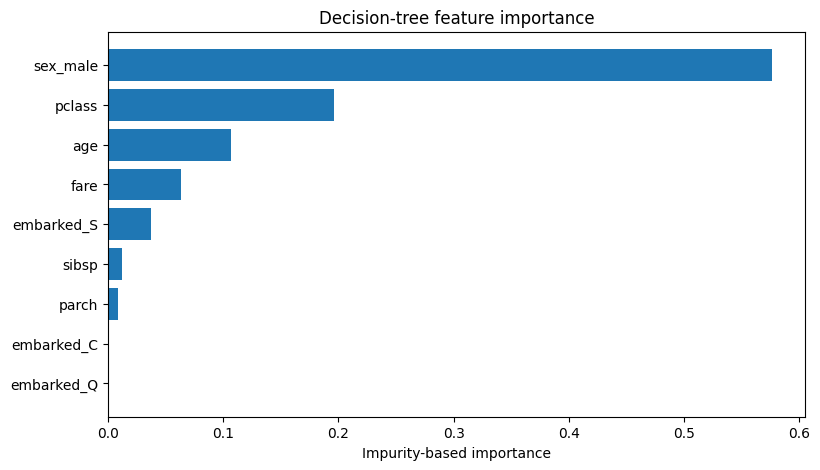

In [4]:
plt.figure(figsize=(9, 5))
plt.barh(
    importance_table["feature"][::-1],
    importance_table["importance"][::-1]
)
plt.xlabel("Impurity-based importance")
plt.title("Decision-tree feature importance")
plt.show()


### Discuss the ranking

Identify:

- the top-ranked transformed feature;
- features with small importance;
- features with zero importance.

Interpret the result narrowly:

> A larger value means that this fitted tree attributed more of its weighted impurity reduction to that transformed feature.

It does **not** mean that the feature has the largest causal effect on survival.


## 4. Connect the ranking back to the tree


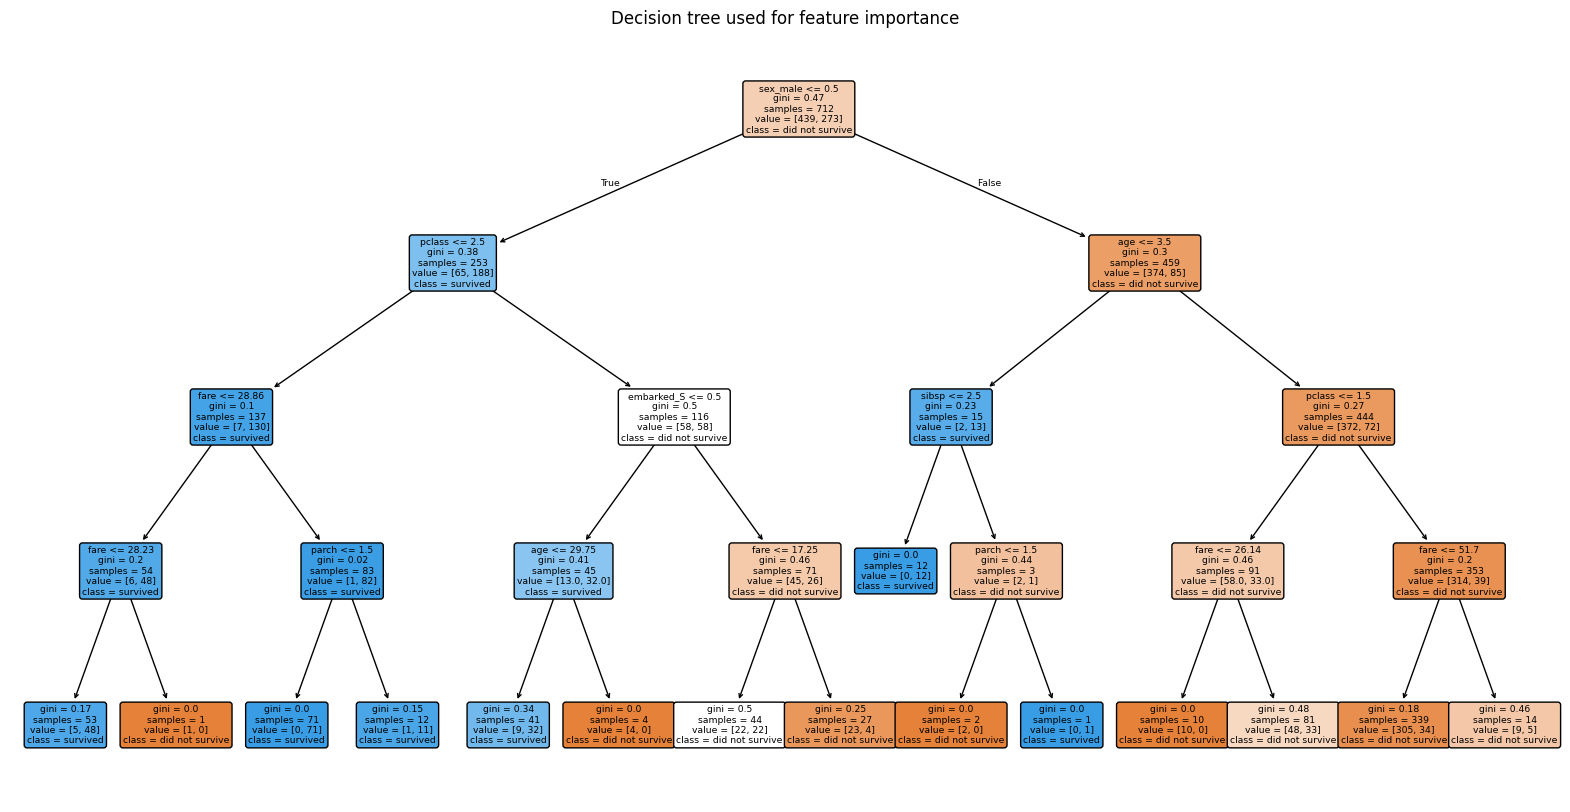

In [5]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["did not survive", "survived"],
    filled=True,
    rounded=True,
    impurity=True,
    precision=2
)

plt.title("Decision tree used for feature importance")
plt.show()


### Discuss the tree and ranking together

Check whether highly ranked features appear high in the tree, repeatedly in the tree, or at splits involving many observations.

A feature with zero importance simply means that **this fitted tree did not use that transformed feature to reduce impurity**. It does not establish that the original variable is unrelated to survival.


## 5. Does importance change with tree complexity?


In [6]:
depth_values = [2, 3, 4, 5, None]
importance_by_depth = []

for max_depth in depth_values:
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_df, y_train)

    for feature, value in zip(
        feature_names,
        model.feature_importances_
    ):
        importance_by_depth.append({
            "max_depth": "None" if max_depth is None else str(max_depth),
            "feature": feature,
            "importance": value
        })

importance_depth_df = pd.DataFrame(importance_by_depth)

pivot_importance = importance_depth_df.pivot(
    index="feature",
    columns="max_depth",
    values="importance"
)

display(pivot_importance)


max_depth,2,3,4,5,None
feature,,,,,
age,0.101970,0.090145,0.106957,0.111294,0.248555
embarked_C,0.000000,0.000000,0.000000,0.000000,0.007947
embarked_Q,0.000000,0.000000,0.000000,0.000000,0.005430
embarked_S,0.000000,0.041015,0.037198,0.034252,0.025544
fare,0.000000,0.004019,0.063141,0.124532,0.243525
parch,0.000000,0.000000,0.008377,0.007714,0.020389
pclass,0.179231,0.216027,0.195920,0.180404,0.109693
sex_male,0.718799,0.635442,0.576297,0.530655,0.315047
sibsp,0.000000,0.013352,0.012109,0.011150,0.023870


### Discuss the depth comparison

If rankings change with depth, that is expected: importance is a property of the **fitted tree**, not a fixed property of the dataset.

Different tree constraints can change:

- which features are selected;
- where they are selected;
- how much impurity reduction is assigned to them.


## 6. Stability of feature importance under resampling


In [7]:
rng = np.random.default_rng(RANDOM_STATE)
records = []

for run in range(40):
    bootstrap_positions = rng.integers(
        0,
        len(X_train_df),
        size=len(X_train_df)
    )

    X_boot = X_train_df.iloc[bootstrap_positions]
    y_boot = y_train.iloc[bootstrap_positions]

    model = DecisionTreeClassifier(
        max_depth=4,
        random_state=run
    )
    model.fit(X_boot, y_boot)

    for feature, value in zip(
        feature_names,
        model.feature_importances_
    ):
        records.append({
            "run": run,
            "feature": feature,
            "importance": value
        })

bootstrap_importance = pd.DataFrame(records)

importance_summary = (
    bootstrap_importance
    .groupby("feature")["importance"]
    .agg(["mean", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(importance_summary)


,mean,std,min,max
feature,,,,
sex_male,0.543815,0.054003,0.392418,0.619731
pclass,0.164575,0.043067,0.082024,0.245802
age,0.134761,0.035873,0.057506,0.241071
fare,0.105031,0.052682,0.027011,0.261563
sibsp,0.018802,0.020259,0.000000,0.070015
embarked_S,0.018361,0.025390,0.000000,0.071226
parch,0.009540,0.013349,0.000000,0.049523
embarked_Q,0.004225,0.012682,0.000000,0.065889
embarked_C,0.000889,0.003381,0.000000,0.017957


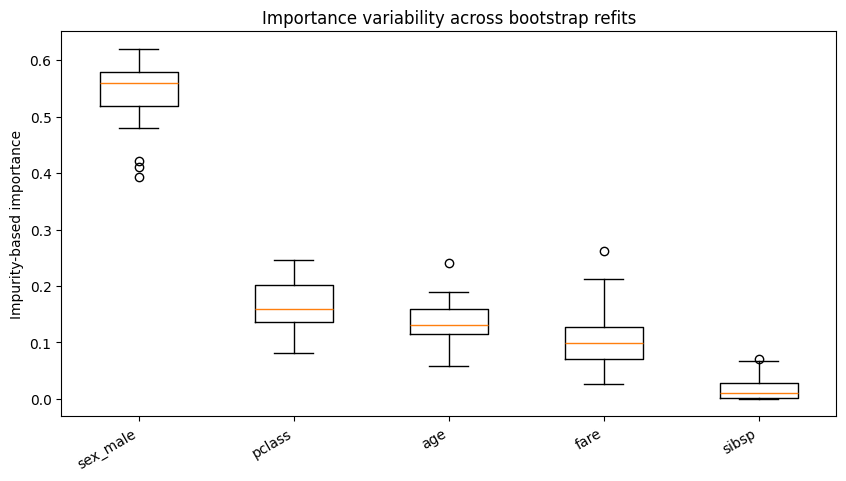

In [8]:
top_features = list(importance_summary.head(5).index)

plot_data = [
    bootstrap_importance.loc[
        bootstrap_importance["feature"] == feature,
        "importance"
    ].values
    for feature in top_features
]

plt.figure(figsize=(10, 5))
plt.boxplot(plot_data, tick_labels=top_features)
plt.ylabel("Impurity-based importance")
plt.title("Importance variability across bootstrap refits")
plt.xticks(rotation=30, ha="right")
plt.show()


### Discuss the stability result

Compare the mean ranking with the spread across bootstrap refits.

A single ranking may look precise even when importance varies substantially across plausible refits. For research interpretation, stability is therefore useful context.


## 7. Scientific cautions

Keep four points in mind:

1. **Model dependence**  
   The ranking describes this fitted tree and its transformed feature representation.

2. **No causal interpretation**  
   Importance does not tell us what would happen if a real-world feature were intervened upon.

3. **Redundant or correlated information**  
   When several features carry overlapping predictive information, a tree may select one and assign little importance to another.

4. **Impurity-based importance can favour features with many potential split points**  
   Continuous or high-cardinality variables can receive misleadingly large impurity-based importance. This is one reason not to treat the ranking as a definitive scientific ordering.

Later lectures can compare this quantity with other feature-importance approaches.


## Student task

Choose two tree depths already explored in the notebook and compare their feature-importance rankings.

1. Report the three highest-ranked transformed features for each tree.
2. Identify any feature whose importance changes substantially.
3. Inspect the corresponding tree structures.
4. Explain why the ranking is a property of the **fitted model**, rather than a fixed property of the dataset.

Do not interpret feature importance as a causal effect on survival.


## 8. Critical discussion

1. What exactly does the highest importance value tell us?
2. Why is a zero importance value narrower than saying “this variable does not matter”?
3. Why can depth change the ranking?
4. Why can bootstrap refits change the ranking?
5. How could correlated or redundant predictors redistribute importance?
6. Why should impurity-based importance not be read as causal evidence?


## 9. Takeaway

Impurity-based feature importance is a **global summary of a fitted tree's impurity reductions**.

It can be useful for model inspection, but the ranking is model-dependent, representation-dependent, potentially unstable, and non-causal.
